In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-cancer-mri-dataset/dataset.csv
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_1402.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_0483.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_0141.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_1531.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_0285.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_0062.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_1891.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_1322.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI d

2026-01-09 13:57:39.072036: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767967059.390208      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767967059.486302      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767967060.509227      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767967060.509278      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767967060.509281      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0

Original Class Distribution:
label
normal          14715
brain_tumor      2048
brain_glioma     2004
brain_menin      2004
Name: count, dtype: int64

Balanced Class Distribution:
label
normal          2004
brain_tumor     2004
brain_glioma    2004
brain_menin     2004
Name: count, dtype: int64

Train: 6412 | Val: 802 | Test: 802
Found 6412 validated image filenames belonging to 4 classes.
Found 802 validated image filenames belonging to 4 classes.
Found 802 validated image filenames belonging to 4 classes.


I0000 00:00:1767967081.569980      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

...

201/201 ━━━━━━━━━━━━━━━━━━━━ 79s 391ms/step - accuracy: 0.9159 - loss: 0.2271 - val_accuracy: 0.9489 - val_loss: 0.1442 - learning_rate: 1.0000e-04
Epoch 9/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 78s 386ms/step - accuracy: 0.9222 - loss: 0.2046 - val_accuracy: 0.9476 - val_loss: 0.1428 - learning_rate: 1.0000e-04
Epoch 10/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 75s 371ms/step - accuracy: 0.9251 - loss: 0.2119 - val_accuracy: 0.9464 - val_loss: 0.1307 - learning_rate: 1.0000e-04
Epoch 11/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 75s 370ms/step - accuracy: 0.9256 - loss: 0.1966 - val_accuracy: 0.9476 - val_loss: 0.1373 - learning_rate: 1.0000e-04
Epoch 12/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 74s 369ms/step - accuracy: 0.9308 - loss: 0.1906 - val_accuracy: 0.9476 - val_loss: 0.1326 - learning_rate: 1.0000e-04
Epoch 13/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.9292 - loss: 0.1912

201/201 ━━━━━━━━━━━━━━━━━━━━ 76s 376ms/step - accuracy: 0.9292 - loss: 0.1912 - val_accuracy: 0.9539 - val_loss: 0.1207 - learning_rate: 1.0000e-04
Epoch 14/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.9334 - loss: 0.1826

201/201 ━━━━━━━━━━━━━━━━━━━━ 75s 375ms/step - accuracy: 0.9334 - loss: 0.1826 - val_accuracy: 0.9576 - val_loss: 0.1200 - learning_rate: 1.0000e-04
Epoch 15/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 74s 369ms/step - accuracy: 0.9365 - loss: 0.1758 - val_accuracy: 0.9501 - val_loss: 0.1187 - learning_rate: 1.0000e-04
Epoch 16/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 75s 371ms/step - accuracy: 0.9430 - loss: 0.1506 - val_accuracy: 0.9564 - val_loss: 0.1170 - learning_rate: 1.0000e-04
Epoch 17/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9387 - loss: 0.1641

201/201 ━━━━━━━━━━━━━━━━━━━━ 75s 373ms/step - accuracy: 0.9388 - loss: 0.1641 - val_accuracy: 0.9601 - val_loss: 0.1056 - learning_rate: 1.0000e-04
Epoch 18/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 76s 377ms/step - accuracy: 0.9400 - loss: 0.1561 - val_accuracy: 0.9564 - val_loss: 0.1059 - learning_rate: 1.0000e-04
Epoch 19/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 76s 379ms/step - accuracy: 0.9452 - loss: 0.1410 - val_accuracy: 0.9526 - val_loss: 0.1103 - learning_rate: 1.0000e-04
Epoch 20/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 76s 380ms/step - accuracy: 0.9480 - loss: 0.1500 - val_accuracy: 0.9589 - val_loss: 0.0987 - learning_rate: 1.0000e-04
Epoch 21/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 75s 373ms/step - accuracy: 0.9470 - loss: 0.1514 - val_accuracy: 0.9539 - val_loss: 0.1038 - learning_rate: 1.0000e-04
Epoch 22/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 74s 368ms/step - accuracy: 0.9512 - loss: 0.1340 - val_accuracy: 0.9576 - val_loss: 0.0945 - learning_rate: 1.0000e-04
Epoch 23/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/st

201/201 ━━━━━━━━━━━━━━━━━━━━ 74s 368ms/step - accuracy: 0.9501 - loss: 0.1320 - val_accuracy: 0.9626 - val_loss: 0.0883 - learning_rate: 1.0000e-04
Epoch 24/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 73s 363ms/step - accuracy: 0.9517 - loss: 0.1256 - val_accuracy: 0.9576 - val_loss: 0.0981 - learning_rate: 1.0000e-04
Epoch 25/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 74s 368ms/step - accuracy: 0.9510 - loss: 0.1322 - val_accuracy: 0.9626 - val_loss: 0.0904 - learning_rate: 1.0000e-04


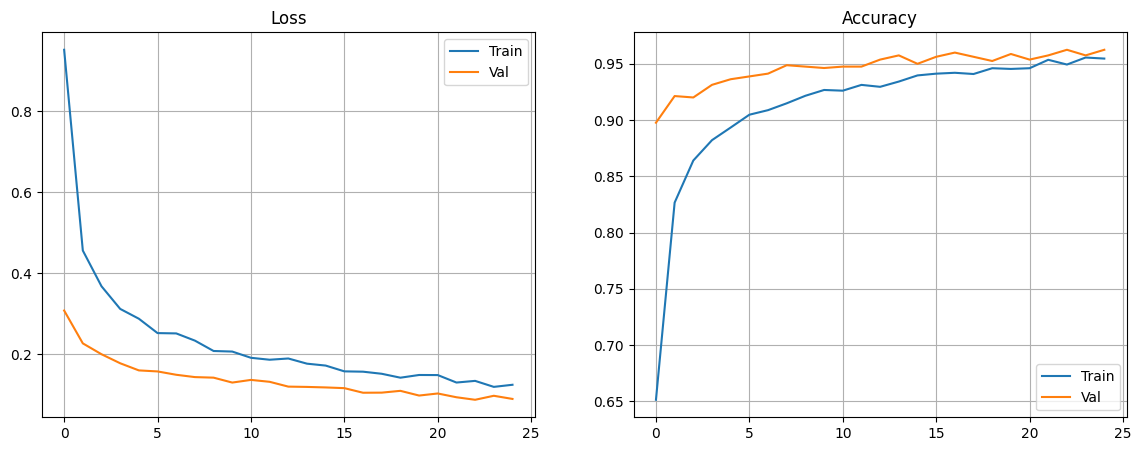

26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 474ms/step


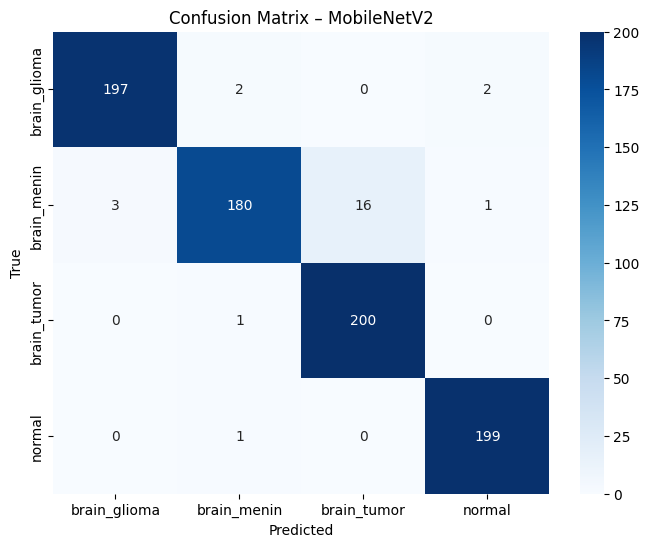


DETAILED METRICS PER CLASS:
              precision    recall  f1-score  support
brain_glioma   0.985000  0.980100  0.982544    201.0
brain_menin    0.978261  0.900000  0.937500    200.0
brain_tumor    0.925926  0.995025  0.959233    201.0
normal         0.985149  0.995000  0.990050    200.0

AVERAGE METRICS:
              precision    recall  f1-score
macro avg      0.968584  0.967531  0.967332
weighted avg   0.968551  0.967581  0.967340

FINAL TRAINING SUMMARY – MOBILENETV2
Model Name              : MobileNetV2
Classes                 : ['brain_glioma', 'brain_menin', 'brain_tumor', 'normal']
Number of Classes       : 4
Train Samples           : 6412
Validation Samples      : 802
Test Samples            : 802
Train Accuracy (Last)   : 0.9548
Best Val Accuracy       : 0.9626
Test Accuracy           : 0.9676
Macro Avg F1-score      : 0.9673
Weighted Avg F1-score   : 0.9673
✅ MobileNetV2 evaluation completed correctly


In [ ]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)

images, labels = [], []

tumor_path = "/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer"
normal_path = "/kaggle/input/brain-mri-images/GAN-Traning Images"

for cls in os.listdir(tumor_path):
    cls_path = os.path.join(tumor_path, cls)
    for img in os.listdir(cls_path):
        if img.lower().endswith(('.png','.jpg','.jpeg')):
            images.append(os.path.join(cls_path, img))
            labels.append(cls)

for img in os.listdir(normal_path):
    if img.lower().endswith(('.png','.jpg','.jpeg')):
        images.append(os.path.join(normal_path, img))
        labels.append("normal")

df = pd.DataFrame({"image": images, "label": labels})

print("\nOriginal Class Distribution:")
print(df["label"].value_counts())

min_count = df["label"].value_counts().min()
balanced = []

for cls in df["label"].unique():
    cls_df = df[df["label"] == cls].sample(min_count, random_state=42)
    balanced.append(cls_df)

df = pd.concat(balanced).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced Class Distribution:")
print(df["label"].value_counts())

train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=df["label"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
IMG_SIZE = (224, 224)
BATCH = 32

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds = train_gen.flow_from_dataframe(
    train_df, x_col="image", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="categorical", shuffle=True
)

val_ds = test_gen.flow_from_dataframe(
    val_df, x_col="image", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="categorical", shuffle=False
)

test_ds = test_gen.flow_from_dataframe(
    test_df, x_col="image", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="categorical", shuffle=False
)

CLASS_NAMES = list(train_ds.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(CLASS_NAMES),
    y=train_df["label"]
)
class_weights = dict(enumerate(weights))

base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(base_model.input, output)

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    ModelCheckpoint("best_mobilenetv2.h5", monitor="val_accuracy", save_best_only=True),
    EarlyStopping(patience=8, restore_best_weights=True),
    ReduceLROnPlateau(patience=4, factor=0.3)
]
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks
)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

test_ds.reset()
preds = model.predict(test_ds)
y_pred = np.argmax(preds, axis=1)
y_true = test_ds.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap="Blues")
plt.title("Confusion Matrix – MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

print("\nDETAILED METRICS PER CLASS:")
print(df_report.iloc[:-3][["precision","recall","f1-score","support"]])

print("\nAVERAGE METRICS:")
print(df_report.loc[["macro avg","weighted avg"],["precision","recall","f1-score"]])

print("\n" + "="*60)
print("FINAL TRAINING SUMMARY – MOBILENETV2")
print("="*60)
print(f"Model Name              : MobileNetV2")
print(f"Classes                 : {CLASS_NAMES}")
print(f"Number of Classes       : {NUM_CLASSES}")
print(f"Train Samples           : {len(train_df)}")
print(f"Validation Samples      : {len(val_df)}")
print(f"Test Samples            : {len(test_df)}")
print(f"Train Accuracy (Last)   : {history.history['accuracy'][-1]:.4f}")
print(f"Best Val Accuracy       : {max(history.history['val_accuracy']):.4f}")
print(f"Test Accuracy           : {df_report.loc['accuracy','precision']:.4f}")
print(f"Macro Avg F1-score      : {df_report.loc['macro avg','f1-score']:.4f}")
print(f"Weighted Avg F1-score   : {df_report.loc['weighted avg','f1-score']:.4f}")
print("="*60)
print("✅ MobileNetV2 evaluation completed correctly")
